In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/dsrscientist/dataset1/master/titanic_train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# seperate the data into numeric and categorical
df_num = df[['Age','SibSp','Parch','Fare']]
df_cat = df[['Survived','Pclass','Sex','Ticket','Cabin','Embarked']]

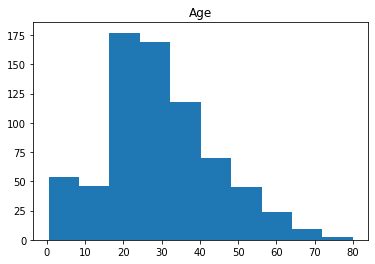

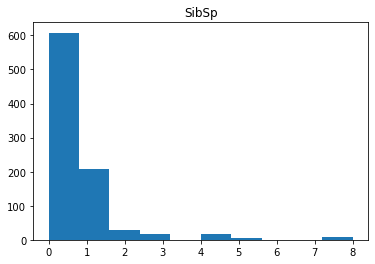

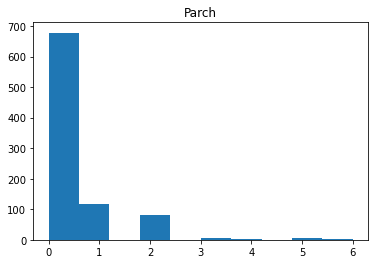

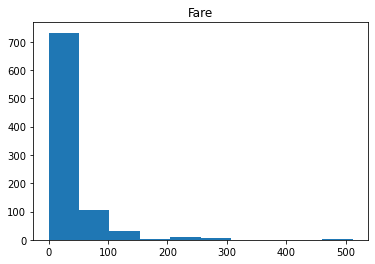

In [6]:
for i in df_num.columns:
    plt.hist(df_num[i])
    plt.title(i)
    plt.show()

So as you can see, most of the distributions are scattered, except Age, it’s pretty normalized. We might consider normalizing them later on. Next, we plot a correlation heatmap between the numeric columns:

In [7]:
df_num.corr()

,Age,SibSp,Parch,Fare
Age,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.308247,1.000000,0.414838,0.159651
Parch,-0.189119,0.414838,1.000000,0.216225
Fare,0.096067,0.159651,0.216225,1.000000


<AxesSubplot:>

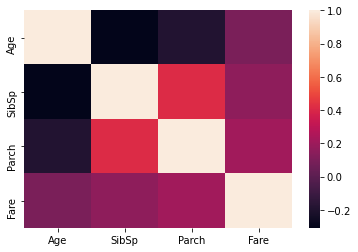

In [8]:
sns.heatmap(df_num.corr())

Here we can see that Parch and SibSp has a higher correlation, which generally makes sense since Parents are more likely to travel with their multiple kids and spouses tend to travel together. Next, let us compare survival rates across the numeric variables. This might reveal some interesting insights:

In [9]:
pd.pivot_table(df, index = 'Survived', values = ['Age','SibSp','Parch','Fare'])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


The inference we can draw from this table is:

 1. The average age of survivors is 28, so young people tend to survive more.
 2. People who paid higher fare rates were more likely to survive, more than double. This might be the people traveling in first-class. Thus the rich survived, which is kind of a sad story in this scenario.
 3. In the 3rd column, If you have parents, you had a higher chance of surviving. So the parents might’ve saved the kids before themselves, thus explaining the rates
 4. And if you are a child, and have siblings, you have less of a chance of surviving

Now we do a similar thing with our categorical variables:

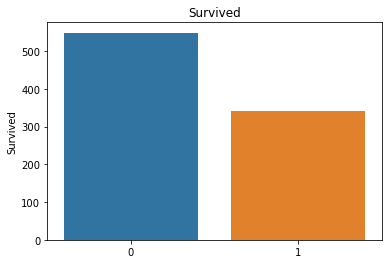

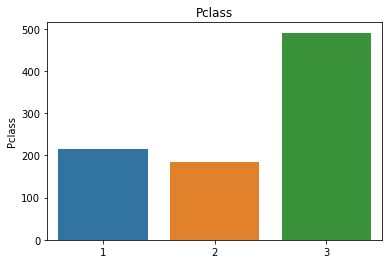

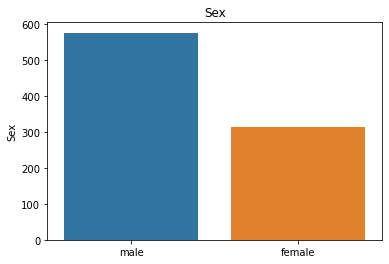

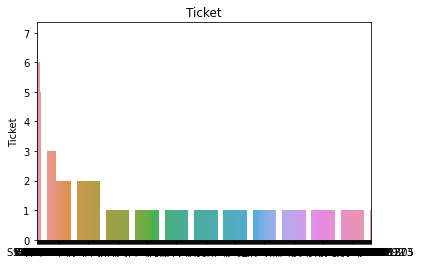

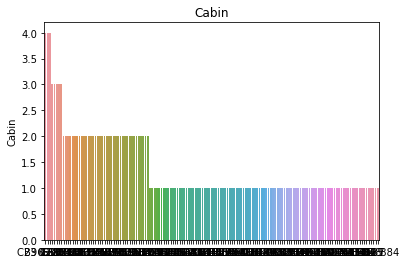

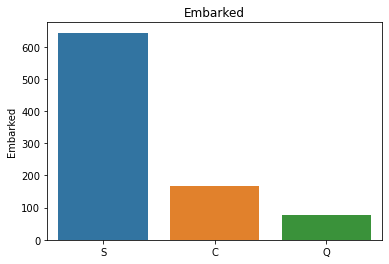

In [10]:
for i in df_cat.columns:
    sns.barplot(df_cat[i].value_counts().index,df_cat[i].value_counts()).set_title(i)
    plt.show()

The Ticket and Cabin graphs look very messy, we might have to feature engineer them! Other than that, the rest of the graphs tells us:

1. Survived: Most of the people died in the shipwreck,  only around 300 people survived.
2. Pclass: The majority of the people traveling, had tickets to the 3rd class.
3. Sex: There were more males than females aboard the ship, roughly double the amount.
4. Embarked: Most of the passengers boarded the ship from Southampton.
 
 Now we will do something similar to the pivot table above, but with our categorical variables, and compare them against our dependent variable, which is if people survived:

In [11]:
print(pd.pivot_table(df, index = 'Survived', columns = 'Pclass',
                     values = 'Ticket' ,aggfunc ='count'))
print()
print(pd.pivot_table(df, index = 'Survived', columns = 'Sex', 
                     values = 'Ticket' ,aggfunc ='count'))
print()
print(pd.pivot_table(df, index = 'Survived', columns = 'Embarked', 
                     values = 'Ticket' ,aggfunc ='count'))

Pclass      1   2    3
Survived              
0          80  97  372
1         136  87  119

Sex       female  male
Survived              
0             81   468
1            233   109

Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217


1. Pclass: Here we can see a lot more people survived from the First class than the Second or the Third class, even though the total number of passengers in the First class was much much less than the Third class. Thus our previous assumption that the rich survived is confirmed here, which might be relevant to model building.
2. Sex: Most of the women survived, and the majority of the male died in the shipwreck. So it looks like the saying “Woman and children first” actually applied in this scenario.
3. Embarked: This doesn’t seem much relevant, maybe if someone was from “Cherbourg” had a higher chance of surviving.

# Feature Engineering

We saw that our ticket and cabin data don’t really make sense to us, and this might hinder the performance of our model, so we have to simplify some of this data with feature engineering.

If we look at the actual cabin data, we see that there’s basically a letter and then a number. The letters might signify what type of cabin it is, where on the ship it is, which floor, which Class it is for, etc. And the numbers might signify the Cabin number. Let us first split them into individual cabins and see whether someone owned more than a single cabin.

In [12]:
df_cat.Cabin
df['cabin_multiple'] = df.Cabin.apply(lambda x: 0 if pd.isna(x) 
                                                    else len(x.split(' ')))
df['cabin_multiple'].value_counts()

0    687
1    180
2     16
3      6
4      2
Name: cabin_multiple, dtype: int64

It looks like the vast majority did not have individual cabins, and only a few people owned more than one cabins. Now let’s see whether the survival rates depend on this:

In [13]:
pd.pivot_table(df, index = 'Survived', columns = 'cabin_multiple',
               values = 'Ticket' ,aggfunc ='count')

cabin_multiple,0,1,2,3,4
Survived,,,,,
0,481.0,58.0,7.0,3.0,NaN
1,206.0,122.0,9.0,3.0,2.0


Next, let us look at the actual letter of the cabin they were in. So you could expect that the cabins with the same letter are roughly in the same locations, or on the same floors, and logically if a cabin was near the lifeboats, they had a better chance of survival. Let us look into that:

In [14]:
# n stands for null
# in this case we will treat null values like it's own category
df['cabin_adv'] = df.Cabin.apply(lambda x: str(x)[0])
#comparing survival rates by cabin
print(df.cabin_adv.value_counts())
pd.pivot_table(df,index='Survived',columns='cabin_adv', 
                        values = 'Name', aggfunc='count')

n    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: cabin_adv, dtype: int64


cabin_adv,A,B,C,D,E,F,G,T,n
Survived,,,,,,,,,
0,8.0,12.0,24.0,8.0,8.0,5.0,2.0,1.0,481.0
1,7.0,35.0,35.0,25.0,24.0,8.0,2.0,NaN,206.0


I did some future engineering on the ticket column and it did not yield many significant insights, which we don’t already know, so I’ll be skipping that part to keep the article concise. We will just divide the tickets into numeric and non-numeric for efficient usage:

In [15]:
df['numeric_ticket'] = df.Ticket.apply(lambda x: 1 if x.isnumeric() else 0)
df['ticket_letters'] = df.Ticket.apply(lambda x: ''.join(x.split(' ')[:-1])
                                            .replace('.','').replace('/','')
                                            .lower() if len(x.split(' ')[:-1]) >0 else 0)

Another interesting thing we can look at is the title of individual passengers. And whether it played any role in them getting a seat in the lifeboats.

In [16]:
df.Name.head(50)
df['name_title'] = df.Name.apply(lambda x: x.split(',')[1]
                                                        .split('.')[0].strip())
df['name_title'].value_counts()

Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Col               2
Mlle              2
Don               1
Lady              1
Ms                1
Mme               1
Capt              1
Sir               1
Jonkheer          1
the Countess      1
Name: name_title, dtype: int64

As you can see, the ship was boarded by people of many different classes, this might be useful for us in our model.

# Data preprocessing for model

In this segment, we make our data, model-ready. The objectives we have to fulfill are listed below:

1. Drop the null values from the Embarked column
2. Include only relevant data
3. Categorically transform all of the data, using something called a transformer.
4. Impute data with the central tendencies for age and fare.
5. Normalize the fare column to have a more normal distribution.
6. using standard scaler scale data 0-1

# Model Deployment

Here we will simply deploy the various models with default parameters and see which one yields the best result. The models can further be tuned for better performance but are not in the scope of this one article. The models we will run are:

* Logistic regression
* K Nearest Neighbour
* Support Vector classifier

First, we import the necessary models

In [17]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import pickle

In [18]:
features = df.drop("Survived", axis=1)
target=df["Survived"]

# Scaling the data using Min-Max Scaler:

In [19]:
from sklearn.preprocessing import MinMaxScaler
mms=MinMaxScaler()
lr=LinearRegression()
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [36]:
X_train = df_num
Y_train = df["Survived"]
X_test  = df.drop("PassengerId", axis=1).copy()

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import GaussianNB